# Premier contrôleur d'exposition SAC

SPY est l'actif tradé. La baseline choisit la direction et le budget de risque. 
SAC choisit directement le multiplicateur financier $A_t \in [0, A_{max}]$ : $A_t = 1$ reproduit la baseline, en dessous il l'atténue, au-dessus il l'amplifie. L'exposition finale est $w_t = \mathrm{clip}(A_t\, w^{base}_t,\ \pm w_{max})$.

La récompense est le P&L net moins une pénalité de risque :

$$r_t = 100\,\Big[\underbrace{w_t\, r_{t+1}}_{\text{P\&L de marché}} - \underbrace{c\,|w_t - w_{t-1}|}_{\text{coût de turnover}} - \underbrace{\lambda_{risk}\,(w_t\, r_{t+1})^2}_{\Psi_{t+1}}\Big]$$

In [1]:
import matplotlib.pyplot as plt

from utils import (
    AgentFeatures,
    MarketDataLoader,
    TrendVolatilityBaseline,
    WalkForwardRunner,
)

## 1. Données en mémoire

In [2]:
# Le chargement precede de deux ans le premier train : vol_regime demande une
# volatilite 21 jours puis sa mediane 252 jours, soit ~273 seances d'echauffement
# perdues au dropna. Sans cette marge, le train du fold 0 serait ampute.
raw_data = MarketDataLoader('SPY', '2014-01-01').load()

3172 jours | 2014-01-03 -> 2026-08-14


## 2. Baseline simple et features de l'agent



In [3]:
# w_max du papier : la meme borne sert a la baseline et au clip applique apres le
# multiplicateur. Une seule source pour les deux, sinon elles divergent en silence.
MAX_EXPOSURE = 2.0
# A_max : a 1.0 SAC ne peut qu'attenuer la baseline. A 2.0 il peut aussi l'amplifier,
# et surtout le milieu de la boite d'action vaut A = 1, donc la baseline elle-meme.
A_MAX = 2.0

baseline = TrendVolatilityBaseline(max_exposure=MAX_EXPOSURE)
agent_features = AgentFeatures()

data = baseline.build(raw_data).join(agent_features.build(raw_data))
state_columns = [*agent_features.columns, 'signal', 'w_base']
data = data.dropna(subset=state_columns)

state_variables = [*state_columns, 'previous_exposure']
print(f'Features agent ({len(agent_features.columns)}) : {agent_features.columns}')
print(f'State SAC ({len(state_variables)}) : {state_variables}')
data[['price', *state_columns]].tail()

Features agent (7) : ['momentum_21', 'momentum_63', 'return_z', 'vol_regime', 'vol_short_long_ratio', 'downside_vol_ratio', 'market_drawdown']
State SAC (10) : ['momentum_21', 'momentum_63', 'return_z', 'vol_regime', 'vol_short_long_ratio', 'downside_vol_ratio', 'market_drawdown', 'signal', 'w_base', 'previous_exposure']


,price,momentum_21,momentum_63,return_z,vol_regime,vol_short_long_ratio,downside_vol_ratio,market_drawdown,signal,w_base
Date,,,,,,,,,,
2026-08-10,773.030029,0.585747,0.706789,-0.033662,0.127038,0.953213,0.602710,-0.000297,1.0,0.714477
2026-08-11,770.559998,0.710580,0.641017,-0.362985,0.104014,0.424418,0.588817,-0.003492,1.0,0.728650
2026-08-12,772.489990,0.685074,0.700401,0.289351,0.100135,0.424967,0.589520,-0.000996,1.0,0.729519
2026-08-13,777.880005,0.754641,0.714594,0.805236,0.100801,0.490871,0.584730,0.000000,1.0,0.723591
2026-08-14,776.340027,0.851347,0.579048,-0.227628,0.082288,0.471175,0.577726,-0.001980,1.0,0.732355


## 3. Protocole financier walk-forward




In [4]:
SAC_CONFIG = {
    # Buffer plus court que total_timesteps : il oublie enfin les transitions les
    # plus anciennes de la fenetre de train, ce que la non-stationnarite demande.
    # A 50k pour 10k pas, le parametre etait inerte.
    'buffer_size': 20_000,
    'learning_starts': 1_000,
    'gamma': 0.96,
    'policy_kwargs': {'net_arch': [64, 64]},
}

# Poids de Psi_{t+1} = (w_t * r_{t+1})^2 dans la recompense. Arbitrage rendement /
# variance, les deux annualises : sans cout, w* = mu / (2 * LAMBDA_RISK * sigma^2).
# A mu ~ 13 % et sigma ~ 18 %, la valeur 2.0 place w* autour de 1.0, du meme ordre
# que la baseline. LAMBDA_RISK = 0.0 redonne exactement l'ancienne recompense, et
# c'est l'ablation a lancer pour mesurer l'apport du terme de risque.
LAMBDA_RISK = 2.0

experiment = WalkForwardRunner(
    sac_config=SAC_CONFIG,
    state_columns=state_columns,
    first_train_start='2016-01-01',
    train_years=4,
    test_years=1,
    # Longueur des episodes d'entrainement, tires au hasard dans la fenetre de train.
    episode_length=252,
    # True : fenetre glissante de 4 annees civiles.
    # False : fenetre extensible
    rolling_train=True,
    seeds=[42,17,23],
    # 30k pas -> a peu pres 120 episodes de 252 jours par fold.
    total_timesteps=30_000,
    transaction_cost_bps=1.0,
    # Bornes definies en cellule 2 : A_max sur le multiplicateur, w_max reapplique
    # apres lui. max_exposure doit rester celui passe a la baseline.
    a_max=A_MAX,
    max_exposure=MAX_EXPOSURE,
    lambda_risk=LAMBDA_RISK,
)

In [5]:
experiment.run(data)
experiment.folds_

Fold 0 | train 2016-01-04 -> 2019-12-31 (1006 j) | test 2020-01-02 -> 2020-12-31


  seed 42 | 215 s | A moyen 0.925 | dispersion 0.766 | sharpe 0.30
  seed 17 | 209 s | A moyen 0.853 | dispersion 0.763 | sharpe 1.27
  seed 23 | 196 s | A moyen 0.813 | dispersion 0.769 | sharpe 0.78
Fold 1 | train 2017-01-03 -> 2020-12-31 (1007 j) | test 2021-01-04 -> 2021-12-31
  seed 42 | 179 s | A moyen 1.116 | dispersion 0.740 | sharpe 0.52
  seed 17 | 168 s | A moyen 1.204 | dispersion 0.690 | sharpe 1.18
  seed 23 | 186 s | A moyen 0.948 | dispersion 0.703 | sharpe 0.78
Fold 2 | train 2018-01-02 -> 2021-12-31 (1008 j) | test 2022-01-03 -> 2022-12-30
  seed 42 | 182 s | A moyen 0.685 | dispersion 0.705 | sharpe -1.14
  seed 17 | 169 s | A moyen 0.539 | dispersion 0.675 | sharpe -1.26
  seed 23 | 170 s | A moyen 0.791 | dispersion 0.738 | sharpe -0.79
Fold 3 | train 2019-01-02 -> 2022-12-30 (1008 j) | test 2023-01-03 -> 2023-12-29
  seed 42 | 167 s | A moyen 0.840 | dispersion 0.727 | sharpe 0.47
  seed 17 | 170 s | A moyen 1.027 | dispersion 0.785 | sharpe 0.26
  seed 23 | 172 s

,train_start,train_end,test_start,test_end
fold,,,,
0,2016-01-04,2019-12-31,2020-01-02,2020-12-31
1,2017-01-03,2020-12-31,2021-01-04,2021-12-31
2,2018-01-02,2021-12-31,2022-01-03,2022-12-30
3,2019-01-02,2022-12-30,2023-01-03,2023-12-29
4,2020-01-02,2023-12-29,2024-01-02,2024-12-31
5,2021-01-04,2024-12-31,2025-01-02,2025-12-31


## 4. Résultats strictement hors échantillon

Les tableaux et la courbe de capital comparent chaque seed SAC, la baseline simple et SPY.

In [6]:
experiment.metrics_.round(3)

,annual_return,annual_volatility,sharpe_0pct,max_drawdown
SAC_seed_42,0.027,0.124,0.280,-0.208
SAC_seed_17,0.110,0.132,0.855,-0.223
SAC_seed_23,0.101,0.123,0.842,-0.158
Baseline,0.054,0.112,0.524,-0.184
SPY,0.149,0.207,0.773,-0.337


In [7]:
experiment.fold_metrics_['sharpe_0pct'].unstack('strategy').round(2)

strategy,Baseline,SAC_seed_17,SAC_seed_23,SAC_seed_42,SPY
fold,,,,,
0,0.20,1.27,0.78,0.30,0.60
1,1.42,1.18,0.78,0.52,2.17
2,-1.54,-1.26,-0.79,-1.14,-0.75
3,0.48,0.26,0.63,0.47,1.85
4,1.43,0.74,1.03,0.39,1.86
5,1.01,2.32,2.31,0.87,0.96


### Comparaison

**SAC bat-il la baseline, et bat-il SPY, en Sharpe OOS, fold par fold ?** La colonne `SAC` est la moyenne des seeds — pas le meilleur seed.

Le Sharpe est invariant à l'échelle : un multiplicateur constant reproduirait exactement celui de la baseline, au coût de turnover près. `A_dispersion` est donc affichée à côté des comparaisons — une victoire adossée à une dispersion proche de zéro ne dit rien de SAC. Elle ne conditionne rien automatiquement, c'est à la lecture du tableau d'en tenir compte.

Le compte de folds gagnés n'est pas un test statistique. Il faudra un bootstrap par blocs apparié sur la série quotidienne OOS concaténée avant toute affirmation dans le papier.

In [8]:
experiment.summary().round(2)

SAC > Baseline : 3/6 folds
SAC > SPY : 2/6 folds


,SAC,Baseline,SPY,A_moyen,A_dispersion,SAC > Baseline,SAC > SPY
fold,,,,,,,
0,0.78,0.20,0.60,0.86,0.77,True,True
1,0.82,1.42,2.17,1.09,0.71,False,False
2,-1.07,-1.54,-0.75,0.67,0.71,True,False
3,0.46,0.48,1.85,0.96,0.73,False,False
4,0.72,1.43,1.86,0.94,0.70,False,False
5,1.83,1.01,0.96,0.95,0.74,True,True


### Décomposition des coûts et saturation

`net = brut − coût` est exact terme à terme, donc cette table isole ce que le turnover retire à chaque stratégie. L'annualisation est **arithmétique** (moyenne × 252) pour que la soustraction reste exacte ; elle ne coïncide donc pas avec `annual_return` de `metrics_`, qui compose.

Le bloc imprimé mesure la saturation de l'action. La récompense étant linéaire en exposition et sans terme de risque, son optimum est sur une borne de $[0, A_{max}]$ : si l'agent y passe l'essentiel de son temps, il fait du tout-ou-rien et non de la modulation.

In [9]:
import pandas as pd

# Memes conventions que l'environnement : rendement du jour suivant, turnover
# contre la position de la veille, position initiale a plat.
d = experiment.decisions_
dates = d.loc[d['seed'] == experiment.seeds[0]].index
annees = len(dates) / 252
r_actif = (data['price'].shift(-1) / data['price'] - 1.0).loc[dates]

expositions = {f'SAC_seed_{s}': d.loc[d['seed'] == s, 'exposure'] for s in experiment.seeds}
expositions['Baseline'] = data.loc[dates, 'w_base']

lignes = {}
for nom, w in expositions.items():
    turnover = w.diff().abs()
    turnover.iloc[0] = abs(w.iloc[0])
    brut = (w * r_actif).mean() * 252
    cout = experiment.cost_rate * turnover.sum() / annees
    lignes[nom] = {
        'turnover/an': turnover.sum() / annees,
        '|w| moyen': w.abs().mean(),
        'brut/an': brut,
        'cout/an': cout,
        'net/an': brut - cout,
    }

# Saturation : un objectif lineaire en exposition a son optimum sur une borne.
q = d['multiplier'].quantile([0, .05, .25, .5, .75, .95, 1]).round(2)
bornes = ((d['multiplier'] < 0.1) | (d['multiplier'] > experiment.a_max - 0.1)).mean()
print(f'quantiles de A : {q.to_dict()}')
print(f'part du temps colle aux bornes : {100 * bornes:.0f} %')

pd.DataFrame(lignes).T.round(4)

quantiles de A : {0.0: 0.0, 0.05: 0.0, 0.25: 0.15, 0.5: 0.81, 0.75: 1.69, 0.95: 1.98, 1.0: 2.0}
part du temps colle aux bornes : 35 %


,turnover/an,|w| moyen,brut/an,cout/an,net/an
SAC_seed_42,107.9605,0.6319,0.0457,0.0108,0.0349
SAC_seed_17,100.3048,0.7423,0.1231,0.0100,0.1131
SAC_seed_23,103.9821,0.6791,0.1141,0.0104,0.1037
Baseline,16.7152,0.7341,0.0604,0.0017,0.0588


## 5. Graphiques finaux

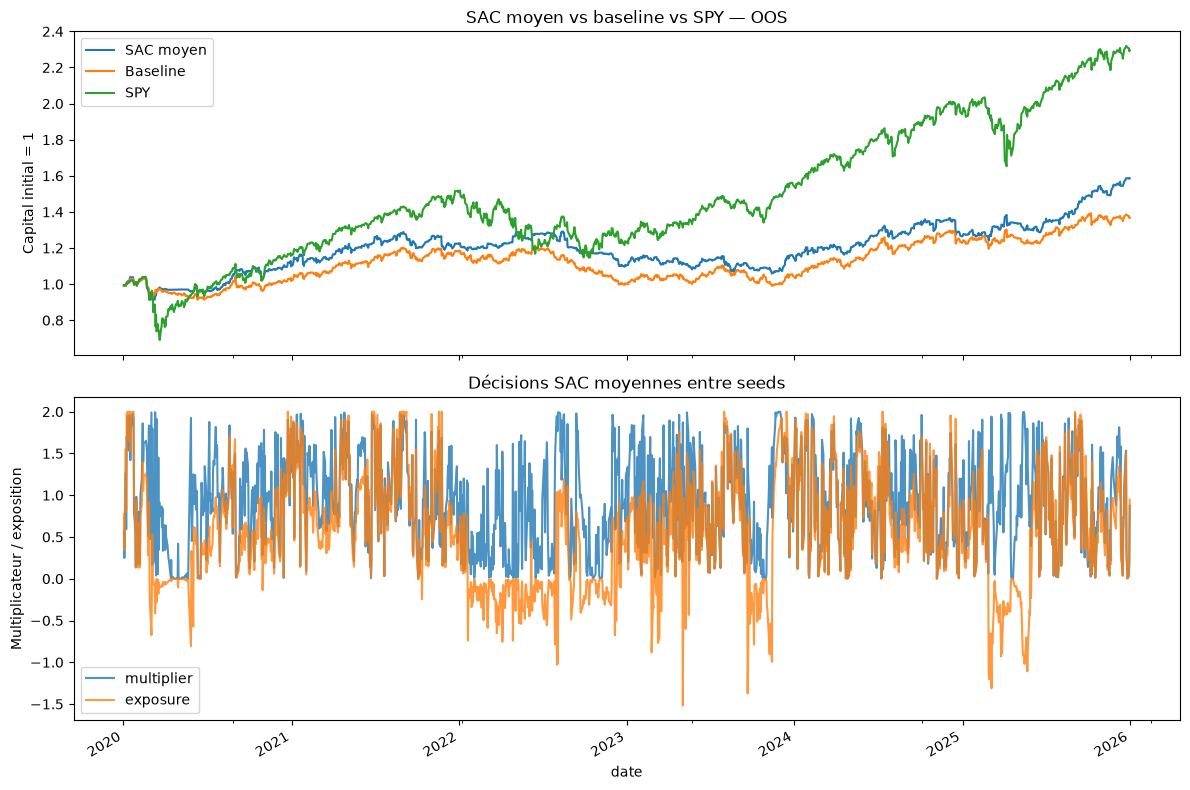

In [10]:
returns = experiment.daily_returns_
comparison = returns[['Baseline', 'SPY']].copy()
comparison.insert(0, 'SAC moyen', returns.filter(like='SAC_seed').mean(axis=1))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
(1 + comparison).cumprod().plot(
    ax=axes[0], title='SAC moyen vs baseline vs SPY — OOS'
)
axes[0].set_ylabel('Capital initial = 1')
experiment.mean_decisions()[['multiplier', 'exposure']].plot(
    ax=axes[1], alpha=0.8, title='Décisions SAC moyennes entre seeds'
)
axes[1].set_ylabel('Multiplicateur / exposition')
plt.tight_layout()
plt.show()

## Points méthodologiques encore ouverts

- **Horizon :** le modèle est désormais continu et actualisé avec $\gamma=0.96$. Le choix de ce discount, soit une masse effective de 25 séances, doit être testé en robustesse (par exemple 0.95, 0.96, 0.97 et 0.99).
- **Instrument :** SPY simplifie le prototype, alors que le papier vise les futures S&P 500. Les résultats finaux ne seront pas directement interchangeables.
- **Calibration de $\lambda_{risk}$ :** la valeur 2.0 vient de $w^\star = \mu/(2\lambda_{risk}\sigma^2)$ avec un $\mu$ estimé *ex post* sur SPY. C'est un choix, pas une mesure. Il faut l'ablation $\lambda_{risk}=0$ et un balayage (0, 1, 2, 4) avant toute affirmation dans le papier.
- **Forme de $\Psi$ :** la pénalité est symétrique, elle taxe autant les fortes hausses que les fortes baisses. Une semi-variance $\big(\min(0, w_t r_{t+1})\big)^2$ ne pénaliserait que la baisse et serait plus proche de l'aversion réelle — à comparer.
- **P&L de marché plutôt que net :** $\Psi$ porte sur $w_t r_{t+1}$ et non sur le rendement après coûts, pour que le coût de turnover — déterministe une fois l'action choisie — n'entre pas au carré dans la pénalité.
